In [517]:
import numpy
from astropy import io
import astropy.units as u
from galpy import potential
from galpy.util import plot as galpy_plot
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
galpy_plot.start_print(axes_labelsize=17.,text_fontsize=12.,
                       xtick_labelsize=15.,ytick_labelsize=15.)

Load the data from `.mrt` 

In [518]:
def unique_galaxies():
    """Return the set of galaxies included in the compilation"""
    raw= io.ascii.read('data/MassModels_Lelli2016c.mrt')
    return set(raw['ID'])

def read_data(galaxy):
    """Return the data for a given galaxy"""
    raw= io.ascii.read('data/MassModels_Lelli2016c.mrt')
    return raw[raw['ID'] == galaxy]

def bulgeless():
    allgals= unique_galaxies()
    out= ()
    for gal in allgals:
        data= read_data(gal)
        if numpy.all(numpy.fabs(data['Vbul']) < 1e-10):
            out= out+(gal,)
    return out

In [519]:
len(unique_galaxies())

175

functions for plotting rotation curves

In [520]:
def plot_obs_rotcurve(galaxy):
    data= read_data(galaxy)
    errorbar(data['R'],data['Vobs'],yerr=data['e_Vobs'],ls='none',color='k')
    xlim(0.,1.1*numpy.amax(data['R']))
    ylim(0.,1.3*numpy.amax(data['Vobs']))
    xlabel(r'$R\,(\mathrm{kpc})$')
    ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')
    galpy_plot.text(r'$\mathrm{{{}}}$'.format(galaxy),size=18.,top_left=True)
    return [0.,1.1*numpy.amax(data['R'])]

def plot_rotcurve_model(RRange,disk_surfdens,disk_hr,halo_virial_mass,halo_conc):
    """Plot the rotation curve over a given range Rrange, 
    for a disk with central surface density disk_surfdens and scale length disk_hr
    and a halo with mass halo_virial_mass anc concentration halo_conc"""
    disk= potential.RazorThinExponentialDiskPotential(amp=disk_surfdens,hr=disk_hr)
    disk.plotRotcurve(Rrange=RRange,overplot=True,label=r'$\mathrm{disk}$')
    halo= potential.NFWPotential(mvir=halo_virial_mass.to_value(1e12*u.Msun),conc=halo_conc,ro=8.,vo=220.)
    halo.plotRotcurve(Rrange=RRange,overplot=True,label=r'$\mathrm{halo}$')
    potential.plotRotcurve(disk+halo,Rrange=RRange,overplot=True,label=r'$\mathrm{total}$')
    plt.legend(loc='upper left', bbox_to_anchor=(0.0,1.2), ncol=3,frameon=False,fontsize=18.)
    return None

In [521]:
galaxy = read_data('UGC08490')
galaxy

ID,D,R,Vobs,e_Vobs,Vgas,Vdisk,Vbul,SBdisk,SBbul
,Mpc,kpc,km / s,km / s,km / s,km / s,km / s,Lsun / pc2,Lsun / pc2
str11,float64,float64,float64,float64,float64,float64,float64,float64,float64
UGC08490,4.65,0.34,38.8,3.69,0.91,27.87,0.0,246.74,0.0
UGC08490,4.65,0.68,50.1,3.69,7.1,39.52,0.0,115.82,0.0
UGC08490,4.65,1.02,60.2,3.69,10.23,44.52,0.0,75.75,0.0
UGC08490,4.65,1.36,68.2,3.69,12.18,46.26,0.0,41.22,0.0
UGC08490,4.65,1.69,72.8,3.69,14.42,45.8,0.0,27.51,0.0
UGC08490,4.65,2.03,75.3,3.69,15.29,45.05,0.0,15.53,0.0
UGC08490,4.65,2.37,76.6,3.69,18.41,43.11,0.0,9.72,0.0
UGC08490,4.65,2.7,77.6,3.69,20.65,41.2,0.0,6.89,0.0


Text(0, 0.5, '$I(r), (\\mathrm{L}_\\odot\\mathrm{pc}^{-2})$')

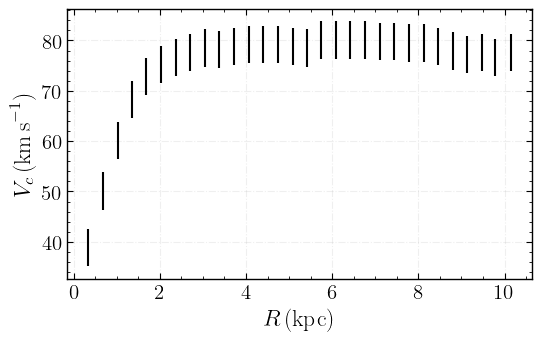

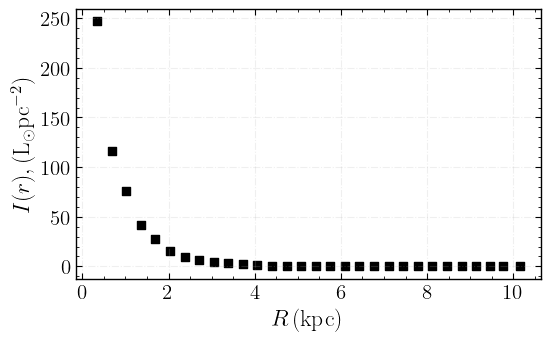

In [522]:
galaxy = read_data('UGC08490')
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy['R'], galaxy['Vobs'], yerr=galaxy['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')

plt.figure(figsize=(6, 3.5))
plt.scatter(galaxy['R'], galaxy['SBdisk'] , marker='s', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$I(r), (\mathrm{L}_\odot\mathrm{pc}^{-2})$')

# 3a) Fit exponential model of surface brightness profile to observed data

Because `UGC08490` is ~ a pure-disk galaxy, we model the surface brightness profile as

$$I(R) = I_0 \exp \left(-\frac{R}{R_d}\right)$$

Below I use $\chi^2$ minimization with `scipy.optimize.minimize` to fit the above profile to the data

In [523]:
import numpy as np
from scipy import stats
from scipy.optimize import minimize

def surfbright_model(R, I0, Rd):
    return I0*np.exp(-R/Rd)

def surf_negloglike(theta, R, SBdisk):
    I0, Rd, log_sigma = theta
    sb_model = surfbright_model(R, I0, Rd)
    return np.sum(-1*stats.norm.logpdf(loc = sb_model, x = SBdisk, scale=np.exp(log_sigma)))


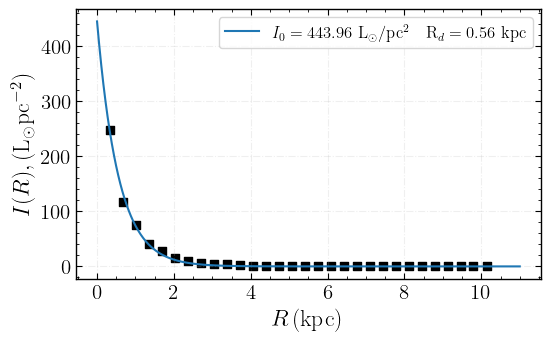

In [524]:
optfunc = lambda theta: surf_negloglike(theta, galaxy['R'], galaxy['SBdisk']) 
theta_0 = [150, 2, 1]
results = minimize(optfunc, theta_0, method='Powell')
results.x

R_array = np.linspace(0, 11, 1000)

plt.figure(figsize=(6, 3.5))
plt.scatter(galaxy['R'], galaxy['SBdisk'] , marker='s', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$I(R), (\mathrm{L}_\odot\mathrm{pc}^{-2})$')
plt.plot(R_array, surfbright_model(R_array, *results.x[0:2]), label=rf'$I_0 = {results.x[0]:.2f}' + r'\ \mathrm L_\odot/ \rm pc^2$ \ \ ' + rf'$\mathrm R_d = {results.x[1]:.2f} \ \rm kpc$')
plt.legend();

Using the results from the above fit, we will plot the contribution of the disk to the total rotation curve.

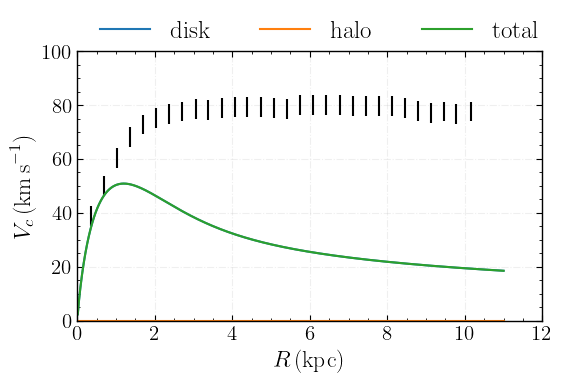

In [525]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy['R'], galaxy['Vobs'], yerr=galaxy['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')
plot_rotcurve_model([0, 11], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, 1e-9*u.M_sun, 1e-9)
plt.ylim(0, 100)
plt.xlim(0, 12);


I notice from the above disk-only model plotted alongside the observed rotation curve that the disk is the dominant contribution to the circular velocities of stars in this galaxy at small radii (R < 1 kpc)

# 3b) By hand, fit an NFW halo to the full observed rotation curve of `UGC08490`

Text(0.5, 1.0, 'Best fit by hand')

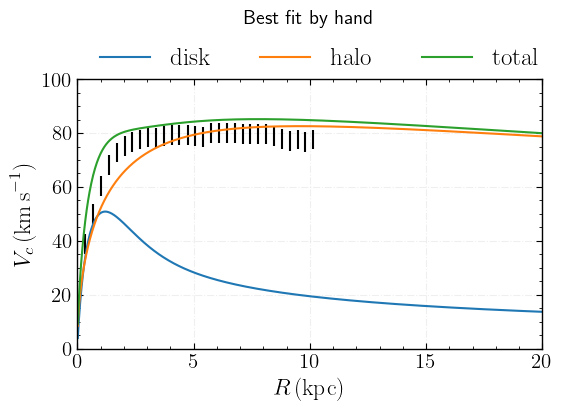

In [526]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy['R'], galaxy['Vobs'], yerr=galaxy['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')

vir_mass_1 = 8e10*u.M_sun
halo_c_1 = 30
plot_rotcurve_model([0, 20], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, vir_mass_1, halo_c_1)
plt.ylim(0, 100)
plt.xlim(0, 20)
plt.title('Best fit by hand', pad=40, family='serif')

`halo_virial_mass`:  Increasing this value showed the primary effect of increasing the v_c value at which the rotation curve plateaued at. Decreasing this value did the inverse. At realistic values, the halo contribution to the rotation curve dominates the disk's at radii > 1 kpc for `UGC08490`

`halo_conc`: Adjusting this value also effects the v_c at which the rotation curve plateaus. Decreasing the concentration means that the peak value is lower. Furthermore, increasing the value of the concentration leads to the 'peak' in the rotation curve (or at least the transition point between rising and flattening) to occur at smaller radii.

The best-fit halo I find tells me that the disk's contribution to the total is only significant at small radii.

# 3c) Repeating 3a,b for two other galaxies.

## galaxy 2

In [527]:
galaxy_2 = read_data('F574-1')

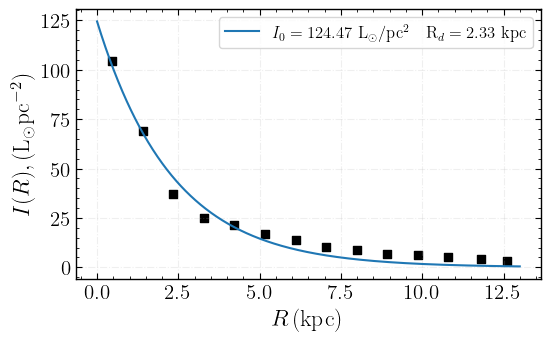

In [528]:
optfunc = lambda theta: surf_negloglike(theta, galaxy_2['R'], galaxy_2['SBdisk']) 
theta_0 = [150, 2, 1]
results = minimize(optfunc, theta_0, method='Powell')
results.x

R_array = np.linspace(0, 13, 1000)

plt.figure(figsize=(6, 3.5))
plt.scatter(galaxy_2['R'], galaxy_2['SBdisk'] , marker='s', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$I(R), (\mathrm{L}_\odot\mathrm{pc}^{-2})$')
plt.plot(R_array, surfbright_model(R_array, *results.x[0:2]), label=rf'$I_0 = {results.x[0]:.2f}' + r'\ \mathrm L_\odot/ \rm pc^2$ \ \ ' + rf'$\mathrm R_d = {results.x[1]:.2f} \ \rm kpc$')
plt.legend();

Text(0.5, 1.1, 'F574-1')

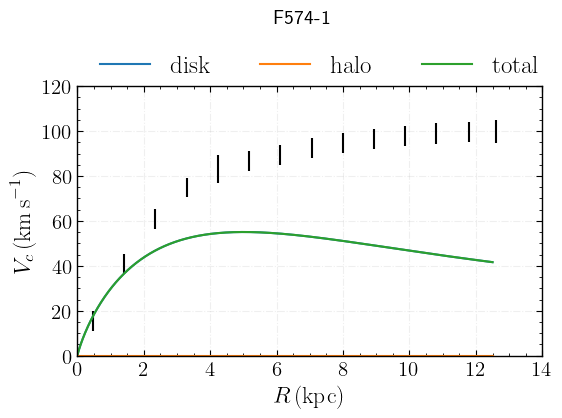

In [529]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy_2['R'], galaxy_2['Vobs'], yerr=galaxy_2['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')
plot_rotcurve_model([0, 12.5], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, 1e-9*u.M_sun, 1e-9)
plt.ylim(0, 120)
plt.xlim(0, 14);
plt.suptitle('F574-1', y=1.1)

Text(0.5, 1.0, 'F574-1: Best fit by hand')

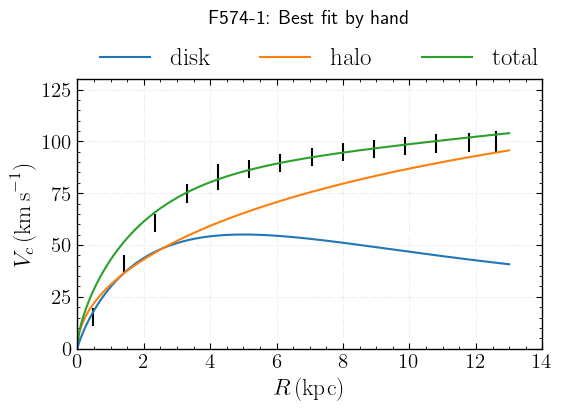

In [530]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy_2['R'], galaxy_2['Vobs'], yerr=galaxy_2['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')
vir_mass_2 = 12e11*u.M_sun
halo_c_2 = 7
plot_rotcurve_model([0, 13], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, vir_mass_2, halo_c_2)
plt.ylim(0, 130)
plt.xlim(0, 14)
plt.title('F574-1: Best fit by hand', pad=40, family='serif')

## galaxy 3

In [531]:
galaxy_3 = read_data('UGCA281')

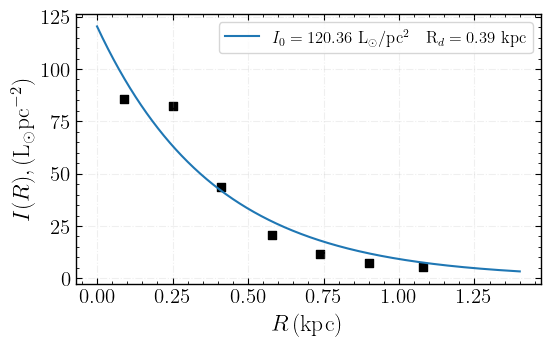

In [532]:
optfunc = lambda theta: surf_negloglike(theta, galaxy_3['R'], galaxy_3['SBdisk']) 
theta_0 = [150, 2, 1]
results = minimize(optfunc, theta_0, method='Powell')
results.x

R_array = np.linspace(0, 1.4, 1000)

plt.figure(figsize=(6, 3.5))
plt.scatter(galaxy_3['R'], galaxy_3['SBdisk'] , marker='s', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$I(R), (\mathrm{L}_\odot\mathrm{pc}^{-2})$')
plt.plot(R_array, surfbright_model(R_array, *results.x[0:2]), label=rf'$I_0 = {results.x[0]:.2f}' + r'\ \mathrm L_\odot/ \rm pc^2$ \ \ ' + rf'$\mathrm R_d = {results.x[1]:.2f} \ \rm kpc$')
plt.legend();

Text(0.5, 1.1, 'UGCA281')

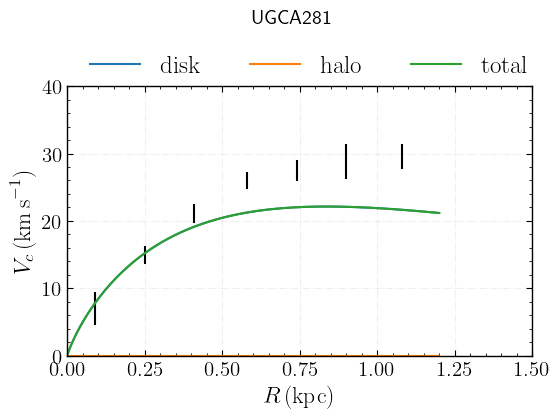

In [533]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy_3['R'], galaxy_3['Vobs'], yerr=galaxy_3['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')
plot_rotcurve_model([0, 1.2], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, 1e-9*u.M_sun, 1e-9)
plt.ylim(0, 40)
plt.xlim(0, 1.5);
plt.suptitle('UGCA281', y=1.1)

Text(0.5, 1.0, 'UGCA281: Best fit by hand')

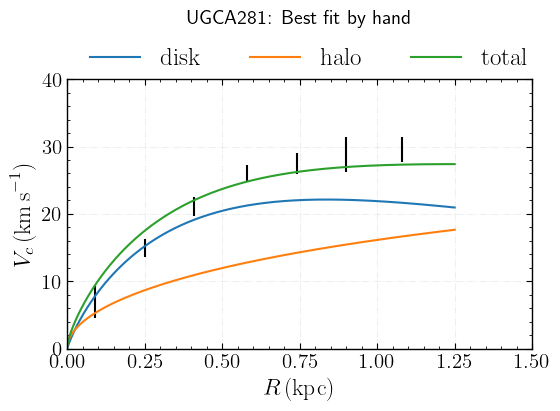

In [534]:
plt.figure(figsize=(6, 3.5))
plt.errorbar(galaxy_3['R'], galaxy_3['Vobs'], yerr=galaxy_3['e_Vobs'], fmt='none', c='k')
plt.xlabel(r'$R\,(\mathrm{kpc})$')
plt.ylabel(r'$V_c\,(\mathrm{km\,s}^{-1})$')

vir_mass_3 = 0.09e11*u.M_sun
halo_c_3 = 10

plot_rotcurve_model([0, 1.25], results.x[0]*u.M_sun/u.pc**2, results.x[1]*u.kpc, vir_mass_3, halo_c_3)
plt.ylim(0, 40)
plt.xlim(0, 1.5)
plt.title('UGCA281: Best fit by hand', pad=40, family='serif')


# 3d) best-fit M_vir and c

In [535]:
from astropy.cosmology import Planck18
def duttonMaccio(mvir):
    a = 0.537 +(1.025-0.537)*np.exp(0) # 0.905
    b = -0.097 #-0.101
    return 10**(a+b*np.log10(mvir/(10**12*(Planck18.h)**-1*u.M_sun)))

def duttonMaccio_2(mvir):
    a = 0.905
    b = -0.101
    return 10**(a+b*np.log10(mvir/(10**12*(Planck18.h)**-1*u.M_sun)))


Text(0, 0.5, '$\\log_{10}\\,c$')

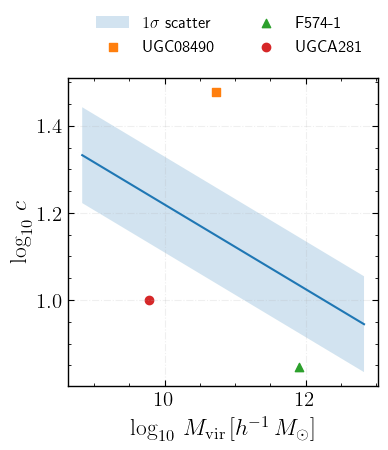

In [536]:
plt.figure(figsize=(4, 4))
mvir_range = np.logspace(9, 13) * u.M_sun
c_range = duttonMaccio(mvir_range)

# convert to h^-1 Msun for x-axis
mvir_h = mvir_range.value * Planck18.h
log_c = np.log10(c_range)

plt.fill_between(np.log10(mvir_h), log_c - 0.11, log_c + 0.11, alpha=0.2, label=r'$1\sigma$ scatter')
plt.plot(np.log10(mvir_h), log_c)
# plt.plot(np.log10(mvir_h), np.log10(duttonMaccio_2(mvir_range)))
plt.scatter(np.log10(vir_mass_1.value*Planck18.h), np.log10(halo_c_1), label='UGC08490', marker='s')
plt.scatter(np.log10(vir_mass_2.value*Planck18.h), np.log10(halo_c_2), label='F574-1', marker='^')
plt.scatter(np.log10(vir_mass_3.value*Planck18.h), np.log10(halo_c_3), label='UGCA281', marker='o')
plt.legend(fontsize=12, bbox_to_anchor=(1, 1.25), ncol=2, frameon=False)
plt.xlabel(r'$\log_{10}\,M_{\rm vir}\,[h^{-1}\,M_\odot]$')
plt.ylabel(r'$\log_{10}\,c$')
# plt.xlim(8, 15.5)
# plt.ylim(0.4, 1.5)

My ($M_{\rm vir}, c$) pairs show large scatter about the predicted relation from Dutton & Macciò. UGC08490 lies well above this relation, while both UGCA281 and F574-1 lies below.

**IF** we assume that my by-hand fitting is a robust statistical modelling approach, the significant offset we see from the predicted relation and the data suggests either a departion from the CDM paradigm or a misunderstanding of baryon effects.